In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("system_working_performance_dataset.csv")

In [3]:
df.head()

,timestamp,cpu_usage,memory_usage,memory_availabale_gb,disk_usage,disk_read_mb,disk_right_md,network_set_mb,network_recive_mb,ping_ms,battery_percent,running_processes,failure
0,2026-08-02 06:03:58,30.6,78.8,550925.33,34.9,0.33,2.23,0.00,0.00,4.07,100,195,0
1,2026-08-02 06:04:04,55.4,79.5,531444.00,34.9,32.03,2.44,0.00,0.00,4.21,100,195,0
2,2026-08-02 06:04:10,64.4,84.4,405318.67,34.9,43.85,37.13,0.53,11.52,6.36,100,202,0
3,2026-08-02 06:04:16,46.2,82.1,464958.67,34.9,27.77,16.77,0.21,1.51,3.91,100,200,0
4,2026-08-02 06:04:22,31.3,82.1,465122.67,34.9,8.13,21.64,0.00,0.00,4.02,100,198,0


In [ ]:
# ping_ms = 104  mean it have messing values

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11800 entries, 0 to 11799
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             11800 non-null  object 
 1   cpu_usage             11800 non-null  float64
 2   memory_usage          11800 non-null  float64
 3   memory_availabale_gb  11800 non-null  float64
 4   disk_usage            11800 non-null  float64
 5   disk_read_mb          11800 non-null  float64
 6   disk_right_md         11800 non-null  float64
 7   network_set_mb        11800 non-null  float64
 8   network_recive_mb     11800 non-null  float64
 9   ping_ms               11696 non-null  float64
 10  battery_percent       11800 non-null  int64  
 11  running_processes     11800 non-null  int64  
 12  failure               11800 non-null  int64  
dtypes: float64(9), int64(3), object(1)
memory usage: 1.2+ MB


timestamp                 0
cpu_usage                 0
memory_usage              0
memory_availabale_gb      0
disk_usage                0
disk_read_mb              0
disk_right_md             0
network_set_mb            0
network_recive_mb         0
ping_ms                 104
battery_percent           0
running_processes         0
failure                   0
dtype: int64

In [ ]:
#fill with median

# Less affected by outliers.
# Good for numerical features like ping.


df["ping_ms"] = df["ping_ms"].fillna(df["ping_ms"].median())

In [ ]:
# remove duplicate value. Since only 104 rows are missing, dropping them is also acceptable

df = df.dropna()

In [ ]:
# check duplicates

print(df.duplicated().sum())

0


In [ ]:
# convert timestamp

# Right now it is an object.

# Convert it to datetime:

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
# after above line i create a usefull feature

df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["dayofweek"] = df["timestamp"].dt.dayofweek

In [ ]:
# For an intern-level project, i can then remove the original timestamp:

f.drop("timestamp", axis=1, inplace=True)

In [ ]:
# since my taregat is failure

print(df["failure"].value_counts())

failure
0    11611
1      189
Name: count, dtype: int64


In [ ]:
#This is important because in my previous output my model achieved 99.95% accuracy, which often indicates an imbalanced dataset.

print(df["failure"].value_counts(normalize=True) * 100)

failure
0    98.398305
1     1.601695
Name: proportion, dtype: float64


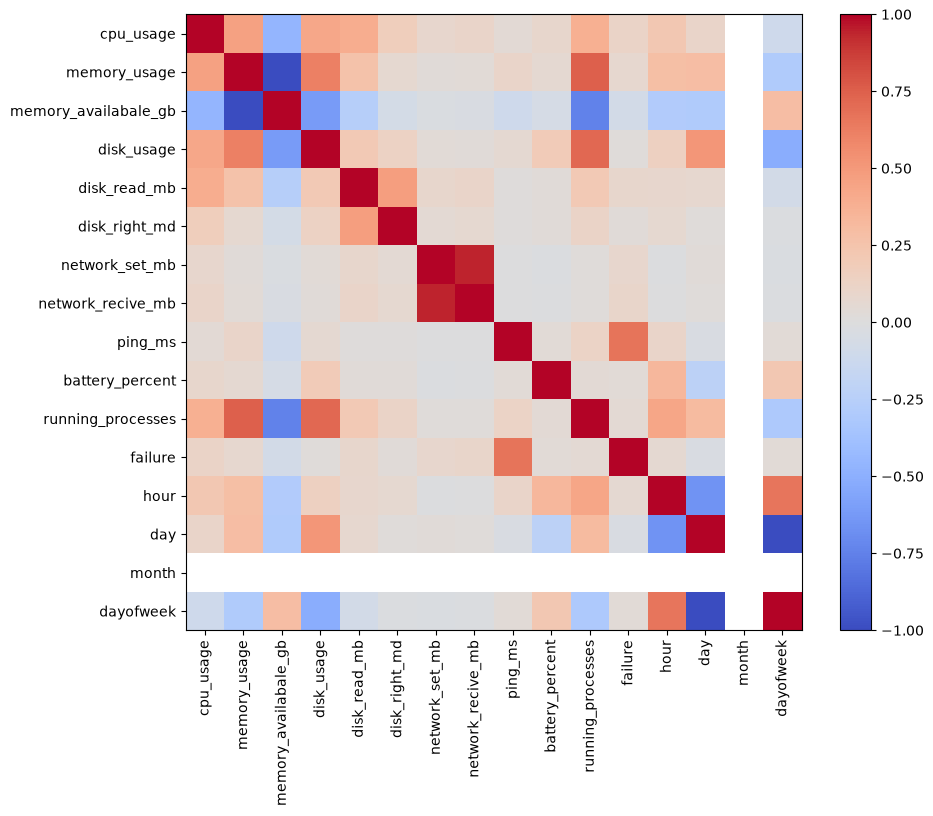

In [ ]:
# Check correlations 

import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [ ]:
# features and target

X = df.drop("failure", axis=1)
y = df["failure"]

In [ ]:
# here i change or correct my category name

df.rename(columns={
    "memory_availabale_gb": "memory_available_gb",
    "disk_right_md": "disk_write_mb",
    "network_set_mb": "network_sent_mb",
    "network_recive_mb": "network_receive_mb"
}, inplace=True)

In [ ]:
# here u can check category
df.head()

,cpu_usage,memory_usage,memory_available_gb,disk_usage,disk_read_mb,disk_write_mb,network_sent_mb,network_receive_mb,ping_ms,battery_percent,running_processes,failure,hour,day,month,dayofweek
0,30.6,78.8,550925.33,34.9,0.33,2.23,0.00,0.00,4.07,100,195,0,6,2,8,6
1,55.4,79.5,531444.00,34.9,32.03,2.44,0.00,0.00,4.21,100,195,0,6,2,8,6
2,64.4,84.4,405318.67,34.9,43.85,37.13,0.53,11.52,6.36,100,202,0,6,2,8,6
3,46.2,82.1,464958.67,34.9,27.77,16.77,0.21,1.51,3.91,100,200,0,6,2,8,6
4,31.3,82.1,465122.67,34.9,8.13,21.64,0.00,0.00,4.02,100,198,0,6,2,8,6


In [ ]:
# train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# missing value handling 

# my assigment says logs can be missing

numeric_features = X.columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

In [ ]:
# build model

model = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)

In [ ]:
# create pipeline

pipeline = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("classifier", model)

    ]

)

In [ ]:
# train pipline

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

In [ ]:
# prediction

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [ ]:
# accuracy

print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.9957627118644068


In [26]:
# classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2322
           1       0.91      0.82      0.86        38

    accuracy                           1.00      2360
   macro avg       0.95      0.91      0.93      2360
weighted avg       1.00      1.00      1.00      2360



In [27]:
# confusion matrix

print(confusion_matrix(y_test, y_pred))

[[2319    3]
 [   7   31]]


In [28]:
# ROC score

print("ROC AUC :", roc_auc_score(y_test, y_prob))

ROC AUC : 0.9989800081599347


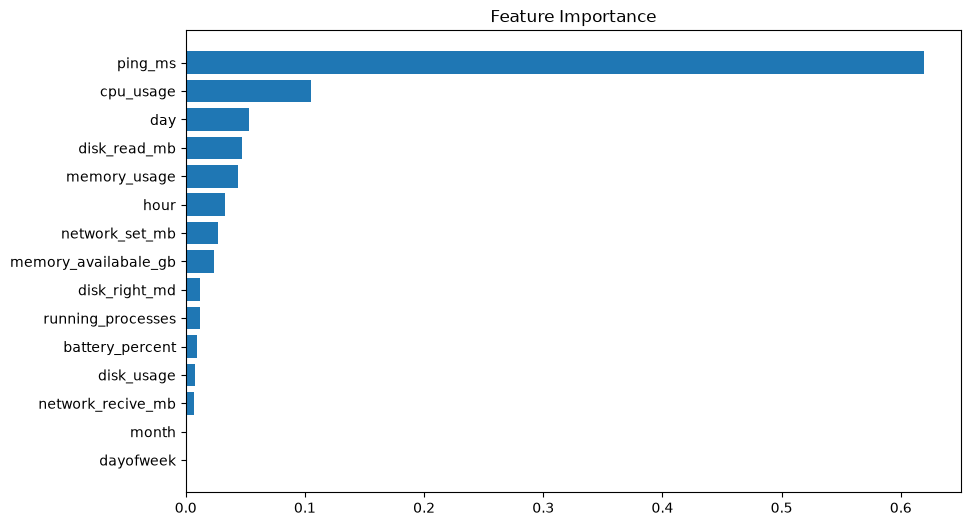

In [29]:
# feature importance

import matplotlib.pyplot as plt

importance = pipeline.named_steps["classifier"].feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

plt.figure(figsize=(10,6))

plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

In [30]:
# save the model

import joblib

joblib.dump(pipeline, "server_failure_model.pkl")

['server_failure_model.pkl']

In [31]:
# load model latter

model = joblib.load("server_failure_model.pkl")

In [40]:
df["memory_used_percent"] = (
    df["memory_usage"] /
    (df["memory_usage"] + df["memory_available_gb"])
) * 100

df["network_total"] = (
    df["network_sent_mb"] +
    df["network_receive_mb"]
)

df["disk_activity"] = (
    df["disk_read_mb"] +
    df["disk_write_mb"]
)

In [35]:
df.head(1)

,cpu_usage,memory_usage,memory_available_gb,disk_usage,disk_read_mb,disk_write_mb,network_sent_mb,network_receive_mb,ping_ms,battery_percent,running_processes,failure,hour,day,month,dayofweek,memory_used_percent
0,30.6,78.8,550925.33,34.9,0.33,2.23,0.0,0.0,4.07,100,195,0,6,2,8,6,0.014301


In [41]:
print(pipeline.named_steps)


{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['cpu_usage', 'memory_usage', 'memory_availabale_gb', 'disk_usage',
       'disk_read_mb', 'disk_right_md', 'network_set_mb', 'network_recive_mb',
       'ping_ms', 'battery_percent', 'running_processes', 'hour', 'day',
       'month', 'dayofweek'],
      dtype='object'))]), 'classifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
     